In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import zipfile 

In [3]:
os.getcwd()
path = '/Users/iriskwon/Documents/Spr26/MLMA Final Project/MLMAMidtermProject' # set directory to your GitHub repo! 

'/Users/iriskwon/Documents/Spr26/MLMA Final Project/MLMAMidtermProject'

In [5]:
with zipfile.ZipFile('merged_data.csv.zip') as z:
    with z.open('merged_data.csv') as f:
        df = pd.read_csv(f)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_56370/1736007017.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


In [6]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


### 0. Visualize class distribution of nurses by stress level!

In [9]:
len(df['id'].unique())
unique_nurses_id = df['id'].unique()
print(unique_nurses_id)

# Convert all IDs to strings to standardize them
df['id'] = df['id'].astype(str)

# Check the unique nurse IDs after standardization
unique_nurses_id = df['id'].unique()
print(f"Number of unique nurse IDs: {len(unique_nurses_id)}")
print(unique_nurses_id)

['15' '5C' '6B' '6D' '7A' '7E' '83' '8B' '94' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']
Number of unique nurse IDs: 15
['15' '5C' '6B' '6D' '7A' '7E' '83' '8B' '94' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']


In [10]:
# Assuming the dataset has columns 'nurse_id' and 'label'
# Group by nurse and label to count occurrences
label_distribution = df.groupby(['id', 'label']).size().reset_index(name='count')

# Pivot the data for visualization 
pivot_table = label_distribution.pivot(index='id',columns='label', values='count').fillna(0)

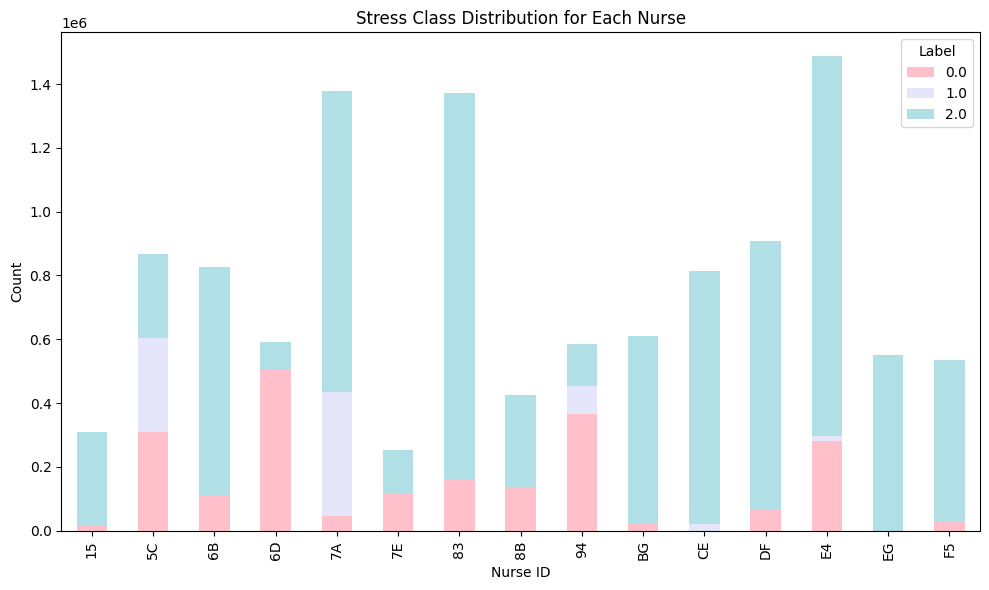

In [11]:
import matplotlib.pyplot as plt 

# Plot the distribution
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color = ['pink','lavender','powderblue'])

plt.title('Stress Class Distribution for Each Nurse')
plt.xlabel('Nurse ID')
plt.ylabel('Count')
plt.legend(title='Label')
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
df.isna().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [13]:
unique_nurses_id

array(['15', '5C', '6B', '6D', '7A', '7E', '83', '8B', '94', 'BG', 'CE',
       'DF', 'E4', 'EG', 'F5'], dtype=object)

In [14]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [15]:
# Transform datetime 
df['datetime'] = pd.to_datetime(df['datetime'])

In [16]:
np.max(df['datetime']), np.min(df['datetime'])

(Timestamp('2020-12-13 08:01:00'), Timestamp('2020-04-14 22:31:00'))

In [17]:
df.columns

Index(['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'id', 'datetime', 'label'], dtype='object')

In [18]:
features = ['X','Y','Z','EDA','HR','TEMP']

In [20]:
processed_df = {}

for pid, df_nurse in df.groupby('id'):
    df_nurse = df_nurse.sort_values('datetime').copy()

    # Normalize per person (safe)
    df_nurse[features] = (df_nurse[features] - df_nurse[features].mean()) / (df_nurse[features].std() + 1e-8)

    # Set time index and convert time-series to windows 
    df_nurse = df_nurse.set_index('datetime')
    window = '60s'  # Used a window of 60 s 

    # Accelerometer magnitude
    df_nurse['acc_mag'] = np.sqrt(
        df_nurse['X']**2 + df_nurse['Y']**2 + df_nurse['Z']**2
    )

    ## FEATURE ENGINEERING STEP ## 
    # Aggregation dictionary for physiological signals (for each window) 
    agg_dict = {
        'HR': ['mean', 'std'],
        'EDA': ['mean', 'std'],
        'TEMP': ['mean', 'std'],
        'acc_mag': ['mean', 'std']
    }
    # Mean to measure baseline level; std for variability of stress signal 

    # Feature aggregation into fixed time windows 
    features_df = df_nurse.resample(window).agg(agg_dict)
    features_df.columns = ['_'.join(col) for col in features_df.columns]

    # Label aggregation (mode)
    label_df = df_nurse['label'].resample(window).agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )

    features_df['label'] = label_df
    # Drop missing
    features_df = features_df.dropna()

    # Convert to seconds since the start of the recording  (continuous)
    features_df['day'] = features_df.index.date

    # get per-day relative time 
    features_df['time_sec'] = (
        features_df.index.to_series()
        .groupby(features_df['day'])
        .transform(lambda x: (x - x.iloc[0]).dt.total_seconds())
    )

    # normalize per day
    features_df['time_sec'] = features_df.groupby('day')['time_sec'].transform(
        lambda x: x / x.max()
    )

    cols = [col for col in features_df.columns if col != 'label'] + ['label']
    features_df = features_df[cols]

    # Save
    features_df.to_csv(f'data/processed_nurse_{pid}.csv')

    # Store processed version
    processed_df[pid] = features_df

In [21]:
processed_df['8B']

,HR_mean,HR_std,EDA_mean,EDA_std,TEMP_mean,TEMP_std,acc_mag_mean,acc_mag_std,day,time_sec,label
datetime,,,,,,,,,,,
2020-07-15 12:56:00,-1.072607,0.067993,-1.155810,0.014095,-0.793795,0.066456,1.810029,0.359060,2020-07-15,0.000000,2.0
2020-07-15 12:57:00,-0.856062,0.095362,-1.139649,0.008144,-0.834868,0.051917,2.027492,0.563624,2020-07-15,0.002183,2.0
2020-07-15 12:58:00,-1.219907,0.090882,-1.128491,0.023127,-1.077779,0.032470,1.651351,0.631843,2020-07-15,0.004367,2.0
2020-07-15 12:59:00,-1.076996,0.088103,-1.146016,0.021961,-1.007588,0.067547,1.442081,0.413175,2020-07-15,0.006550,2.0
2020-07-15 13:00:00,-1.176566,0.030043,-1.165405,0.006417,-1.121611,0.073082,1.287391,0.262066,2020-07-15,0.008734,2.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-07-22 19:03:00,0.033042,0.032371,-0.358033,0.071228,0.248657,0.196888,1.571955,0.329307,2020-07-22,0.428571,2.0
2020-07-22 19:04:00,0.222459,0.059079,-0.297832,0.064532,0.459232,0.034582,1.452384,0.323462,2020-07-22,0.571429,2.0
2020-07-22 19:05:00,0.203852,0.077448,-0.290645,0.079012,0.427354,0.013465,1.442577,0.283164,2020-07-22,0.714286,2.0


In [22]:
processed_df['8B']

,HR_mean,HR_std,EDA_mean,EDA_std,TEMP_mean,TEMP_std,acc_mag_mean,acc_mag_std,day,time_sec,label
datetime,,,,,,,,,,,
2020-07-15 12:56:00,-1.072607,0.067993,-1.155810,0.014095,-0.793795,0.066456,1.810029,0.359060,2020-07-15,0.000000,2.0
2020-07-15 12:57:00,-0.856062,0.095362,-1.139649,0.008144,-0.834868,0.051917,2.027492,0.563624,2020-07-15,0.002183,2.0
2020-07-15 12:58:00,-1.219907,0.090882,-1.128491,0.023127,-1.077779,0.032470,1.651351,0.631843,2020-07-15,0.004367,2.0
2020-07-15 12:59:00,-1.076996,0.088103,-1.146016,0.021961,-1.007588,0.067547,1.442081,0.413175,2020-07-15,0.006550,2.0
2020-07-15 13:00:00,-1.176566,0.030043,-1.165405,0.006417,-1.121611,0.073082,1.287391,0.262066,2020-07-15,0.008734,2.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-07-22 19:03:00,0.033042,0.032371,-0.358033,0.071228,0.248657,0.196888,1.571955,0.329307,2020-07-22,0.428571,2.0
2020-07-22 19:04:00,0.222459,0.059079,-0.297832,0.064532,0.459232,0.034582,1.452384,0.323462,2020-07-22,0.571429,2.0
2020-07-22 19:05:00,0.203852,0.077448,-0.290645,0.079012,0.427354,0.013465,1.442577,0.283164,2020-07-22,0.714286,2.0


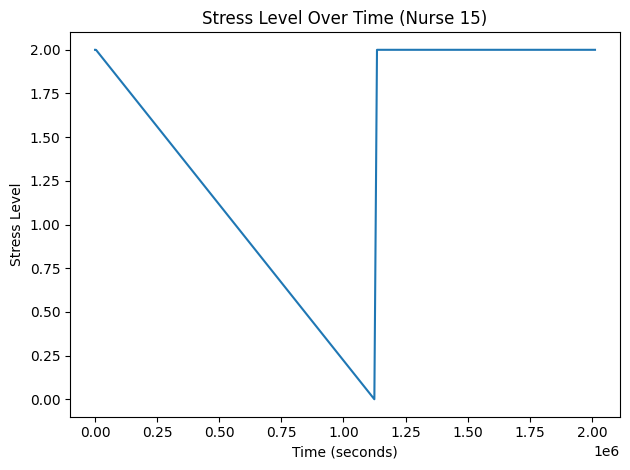

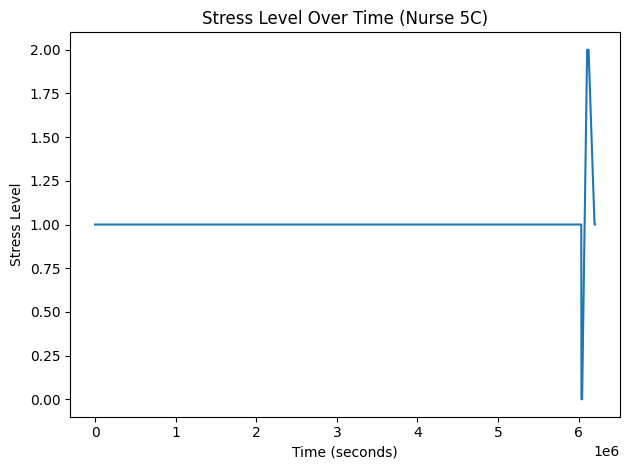

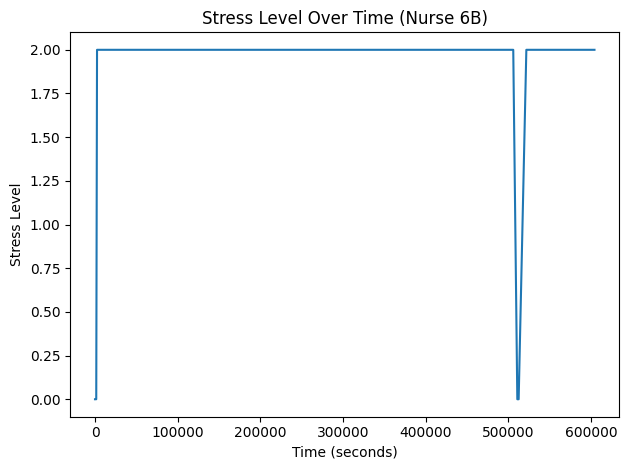

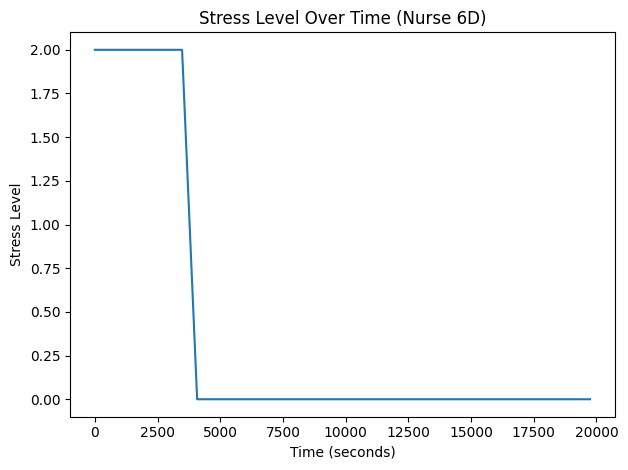

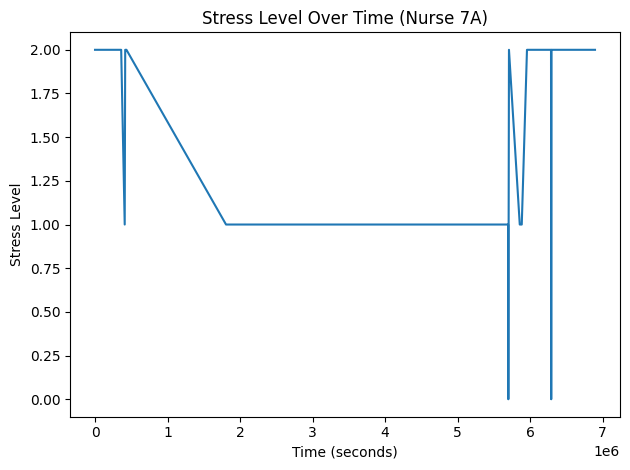

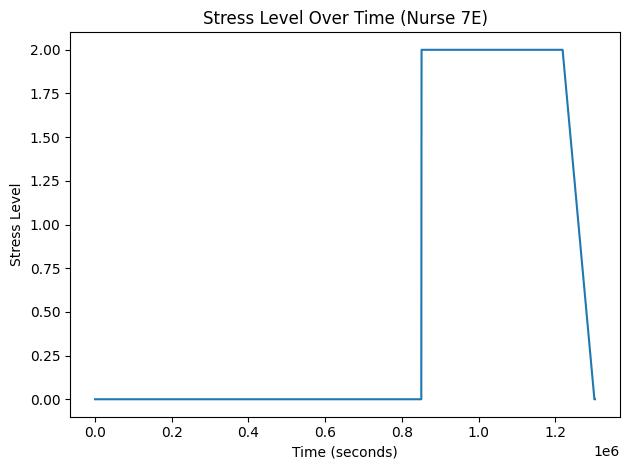

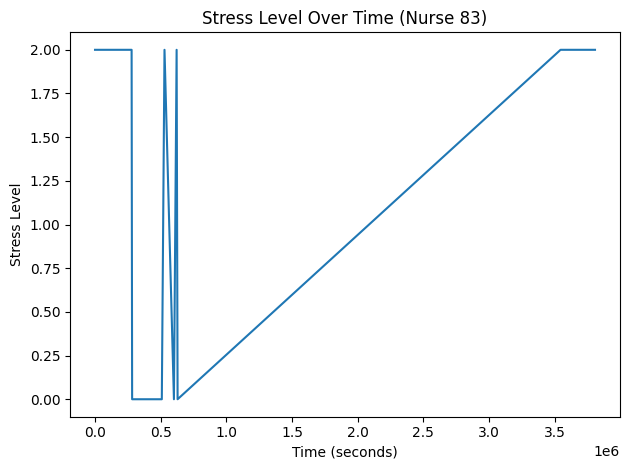

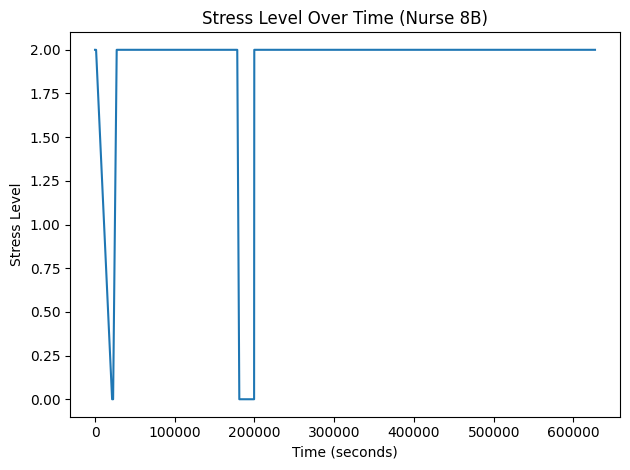

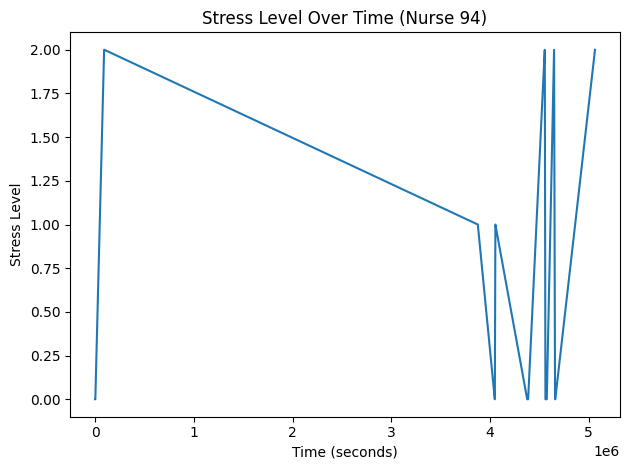

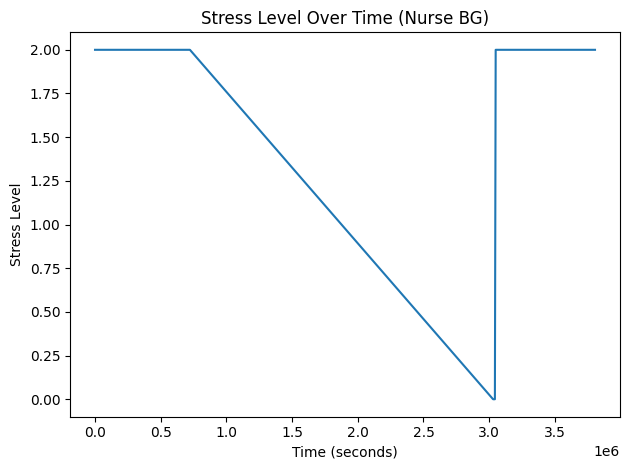

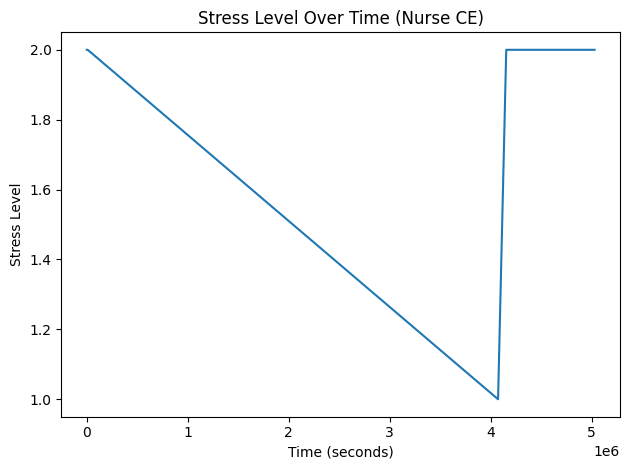

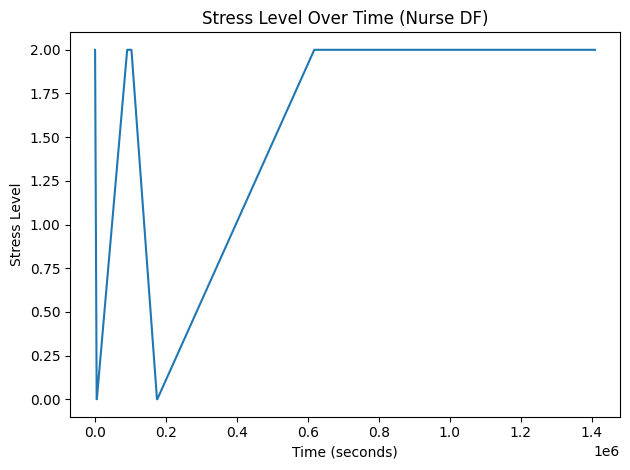

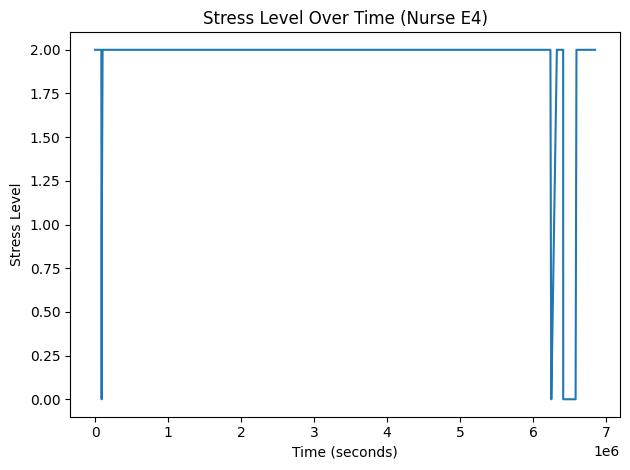

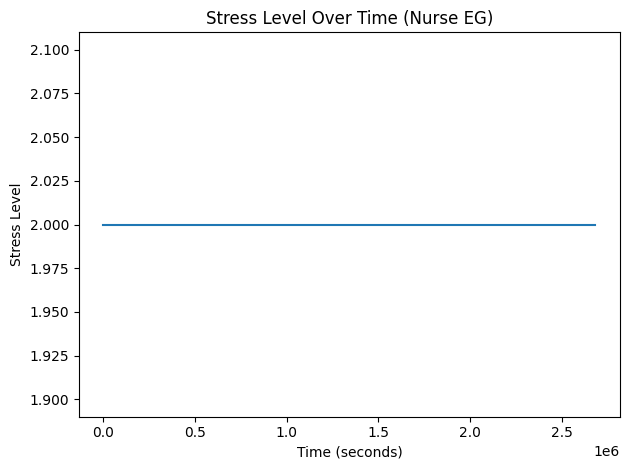

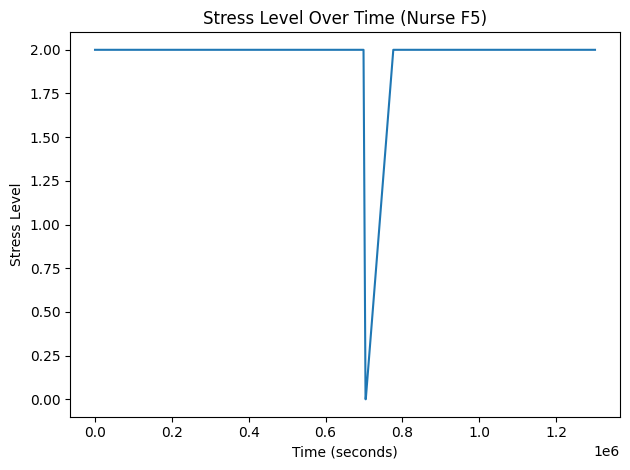

In [23]:
import matplotlib.pyplot as plt

for pid, df_nurse in processed_df.items():
    plt.figure()
    
    # Convert index (datetime) → seconds since start
    time_sec = (df_nurse.index - df_nurse.index[0]).total_seconds()
    
    plt.plot(time_sec, df_nurse['label'])
    
    plt.title(f'Stress Level Over Time (Nurse {pid})')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Stress Level')
    
    plt.tight_layout()
    plt.show()

# other

In [7]:
df['label'].unique()
df['label'].value_counts()

,count
label,
2.0,8540583
0.0,2162246
1.0,806222


In [10]:
label_counts = df['label'].value_counts()
ratio = label_counts[2.0] / label_counts[0.0]
print(f"Ratio of label 2.0 to label 0.0 counts: {ratio}")

Ratio of label 2.0 to label 0.0 counts: 3.9498664814271827


In [11]:
df.groupby('id')['label'].value_counts()

id  label
15  2.0       248703
    0.0        13441
83  2.0      1147516
    0.0       163204
94  0.0       348874
    2.0        87956
    1.0        87458
15  2.0        46987
5C  0.0       309121
    1.0       295685
    2.0       261124
6B  2.0       718027
    0.0       107522
6D  0.0       503041
    2.0        88322
7A  2.0       942743
    1.0       388517
    0.0        46082
7E  2.0       136323
    0.0       117124
83  2.0        62099
8B  2.0       285520
    0.0       138243
94  2.0        44529
    0.0        17279
BG  2.0       587533
    0.0        21122
CE  2.0       794886
    1.0        19201
DF  2.0       842886
    0.0        65282
E4  2.0      1191320
    0.0       281190
    1.0        15361
EG  2.0       549124
F5  2.0       504985
    0.0        30721
Name: count, dtype: int64

In [1]:
df.groupby('label')[['HR','EDA','TEMP']].mean()

NameError: name 'df' is not defined